In [1]:
import dg_geometry as DG503
import sympy as sp
import numpy as np

S214181

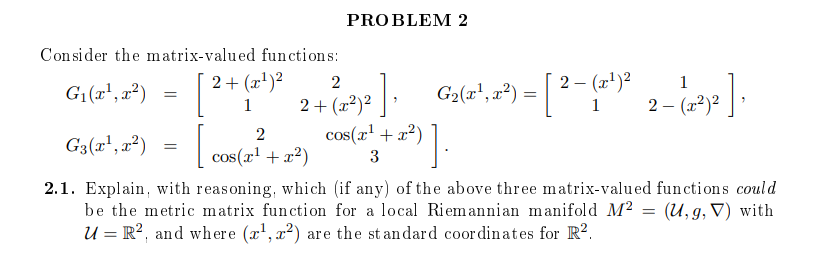

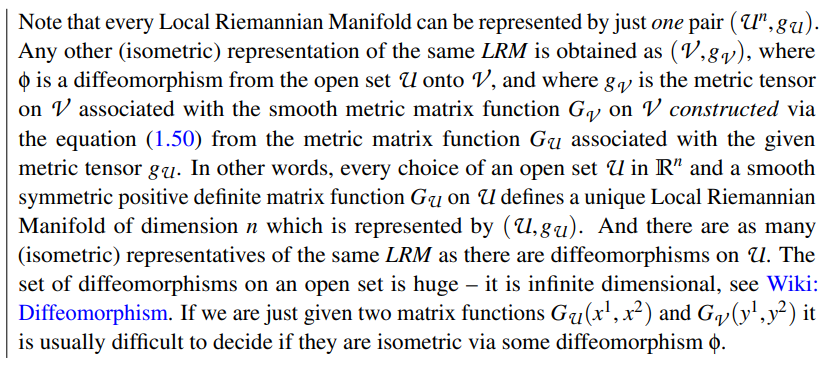

In [2]:
x1, x2 = sp.symbols('x1 x2', real=True)
G1 = sp.Matrix([[2 + x1**2, 2], [1, 2 + x2**2]])
G2 = sp.Matrix([[2 - x1**2, 1], [1, 2 - x2**2]])
G3 = sp.Matrix([[2, sp.cos(x1 + x2)], [sp.cos(x1 + x2), 3]])

print("G1 is symmetric",G1 == G1.T)
print("G2 is symmetric",G2 == G2.T)
print("G3 is symmetric",G3 == G3.T)

detG1 = G1.det()
detG2 = G2.det()
detG3 = G3.det()

print("Determinant of G1:", detG1)
print("Determinant of G2:", detG2)
print("Determinant of G3:", detG3)

G1 is symmetric False
G2 is symmetric True
G3 is symmetric True
Determinant of G1: x1**2*x2**2 + 2*x1**2 + 2*x2**2 + 2
Determinant of G2: x1**2*x2**2 - 2*x1**2 - 2*x2**2 + 3
Determinant of G3: 6 - cos(x1 + x2)**2


### Problem 2.1: Metric matrix check

- $G_1$ is not a valid metric matrix because it is not symmetric: the $(1,2)$ entry is $2$ while the $(2,1)$ entry is $1$.
- $G_2$ is symmetric and where it is positive definite. $\text{determinant} = (2 - (x^1)^2)(2 - (x^2)^2) - 1 > 0$.
 This is negative if $x^1$ and $x^2$ is more than $\sqrt2$ so it is not a local rimmenian manifold
- $G_3$ is symmetric and its determinant is $6 - \cos^2(x^1 + x^2)$. Since $\cos^2(\theta) \le 1$, the determinant is at least $5$, which is always positive. so it is local Riemannian Manifold.

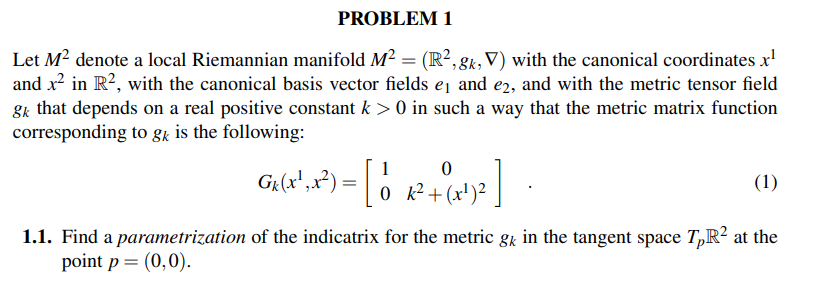

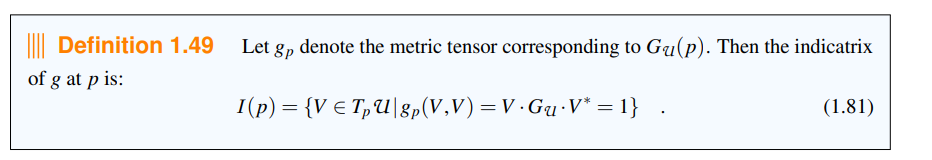

In [3]:
x1, x2, k = sp.symbols('x1 x2 k', real=True)

GK = sp.Matrix([[1 , 0], [0, k**2 +x1**2]])

display(GK)

Matrix([
[1,            0],
[0, k**2 + x1**2]])

In [4]:
v1, v2 = sp.symbols('v1 v2', real=True)

GK_00 = GK.subs(x1, 0).subs(x2, 0)
display(GK_00)

Matrix([
[1,    0],
[0, k**2]])

In [5]:
V = sp.Matrix([[v1], [v2]])

I = V.T * GK_00 * V

eq = sp.Eq(I[0], 1)
display(eq)

Eq(k**2*v2**2 + v1**2, 1)

In [6]:
theta = sp.symbols('theta', real=True)
V = sp.Matrix([[sp.cos(theta)], [sp.sin(theta)/k]])

display(V)
display(V.T * GK_00 * V)
display(sp.simplify(V.T * GK_00 * V))

Matrix([
[  cos(theta)],
[sin(theta)/k]])

Matrix([[sin(theta)**2 + cos(theta)**2]])

Matrix([[1]])

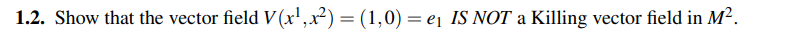

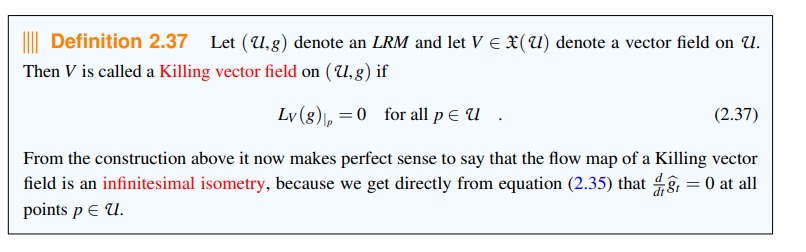

In [7]:
x1, x2 = sp.symbols('x1 x2', real=True)
coords = [x1, x2]
V = sp.Matrix([[1], [0]])

Lv_g = DG503.calculate_lie_derivative_metric(GK, V,coords)

display(Lv_g)

Matrix([
[0,    0],
[0, 2*x1]])

It is not a killing vector field

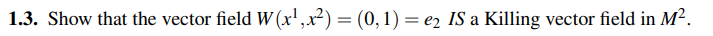

In [8]:
x1, x2 = sp.symbols('x1 x2', real=True)
coords = [x1, x2]
V = sp.Matrix([[0], [1]])

Lv_g = DG503.calculate_lie_derivative_metric(GK, V,coords)

display(Lv_g)

Matrix([
[0, 0],
[0, 0]])

It is a killing vector field

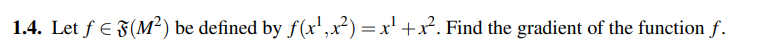

In [9]:
f = x1 + x2
grad_f = DG503.calculate_gradient(GK, f, coords)
display(grad_f)

Matrix([
[               1],
[1/(k**2 + x1**2)]])

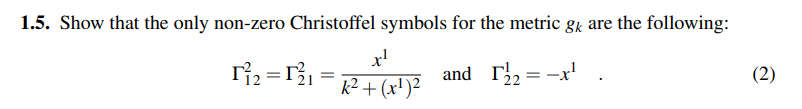

In [41]:
christoffel_symbols = DG503.calculate_christoffel_symbols(GK, coords)
display(christoffel_symbols[0,1,1])
display(christoffel_symbols[1,1,0])

x1/(k**2 + x1**2)

-x1

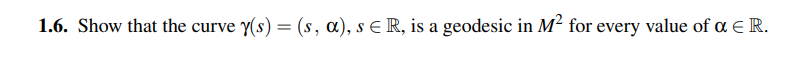
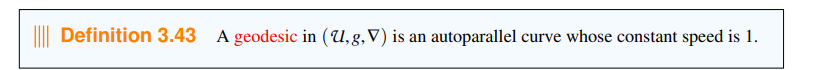

In [11]:
alpha, s = sp.symbols('alpha s', real=True)

coords = [x1, x2]
gamma = sp.Matrix([[s], [alpha]])
gamma_dot = sp.diff(gamma, s)

speed = sp.sqrt(DG503.calculate_g_norm(GK, gamma_dot))
display(speed)

acceleration = DG503.calculate_covariant_derivative_along_curve(GK, gamma, gamma_dot, s, coords)
display(acceleration)

1

Matrix([
[0],
[0]])

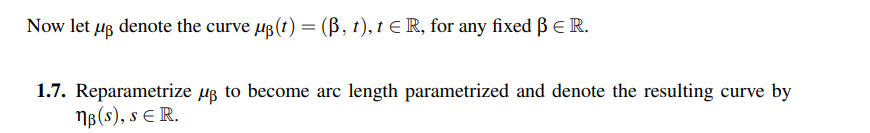

In [ ]:
beta, t, tau = sp.symbols('beta t tau', real=True)

mu_beta = sp.Matrix([[beta], [t]])
mu_beta_dot = sp.diff(mu_beta, t)
display(GK.subs(x1,beta))

mu_beta_dot = DG503.calculate_g_norm(GK.subs(x1,beta), mu_beta_dot)
display(mu_beta_dot)

arc_length = sp.integrate(mu_beta_dot, (tau, 0, t))
display(arc_length)

solved_arc_length_s = sp.solve(sp.Eq(arc_length, s), t)[0]
display(solved_arc_length_s)

mu_beta_s = sp.Matrix([[beta], [solved_arc_length_s]])
display(mu_beta_s)

Matrix([
[1,              0],
[0, beta**2 + k**2]])

sqrt(beta**2 + k**2)

t*sqrt(beta**2 + k**2)

s/sqrt(beta**2 + k**2)

Matrix([
[                  beta],
[s/sqrt(beta**2 + k**2)]])

In [13]:
acceleration_mu_beta_s = DG503.calculate_curve_acceleration(GK, mu_beta_s, s, coords)
display(acceleration_mu_beta_s)

Matrix([
[-beta/(beta**2 + k**2)],
[                     0]])

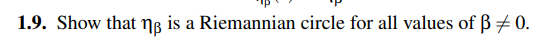

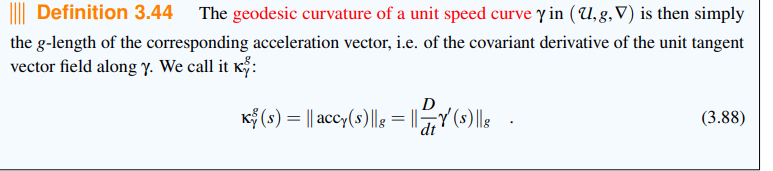

In [14]:
curvature_mu_beta_s = DG503.calculate_g_norm(GK, acceleration_mu_beta_s)
display(curvature_mu_beta_s)

Abs(beta)/(beta**2 + k**2)

Since it is constant it must be circle everywhere but at 0 where it is a point

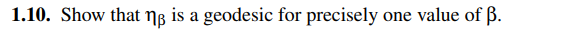

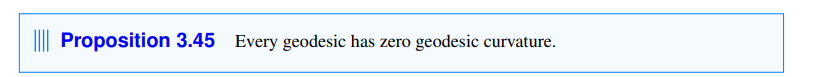

In [27]:
eq = sp.Eq(curvature_mu_beta_s , 0)
display(eq)

geodesic_solutions = sp.solve(eq, beta)
display(geodesic_solutions[0])


Eq(Abs(beta)/(beta**2 + k**2), 0)

0

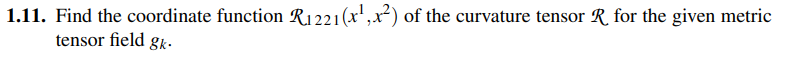

In [26]:
R_1221_tensor = DG503.curvature_tensor(GK, coords)
display(R_1221_tensor[0,1,1,0])

-k**2/(k**2 + x1**2)

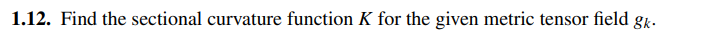

In [24]:
a, b = sp.symbols('a b', real=True)
point = sp.Matrix([[x1], [x2]])

sectional_curvature = DG503.sectional_curvature(GK, point, sp.Matrix([[x1], [x2]]), sp.Matrix([[-x2], [x1]]), coords)
display(sp.simplify(sectional_curvature))

-k**2/(k**4 + 2*k**2*x1**2 + x1**4)

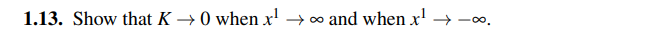

In [23]:
K_infi = sp.limit(sectional_curvature, x1, sp.oo)
K_minus_infi = sp.limit(sectional_curvature, x1, -sp.oo)
display(K_infi)
display(K_minus_infi)

0

0

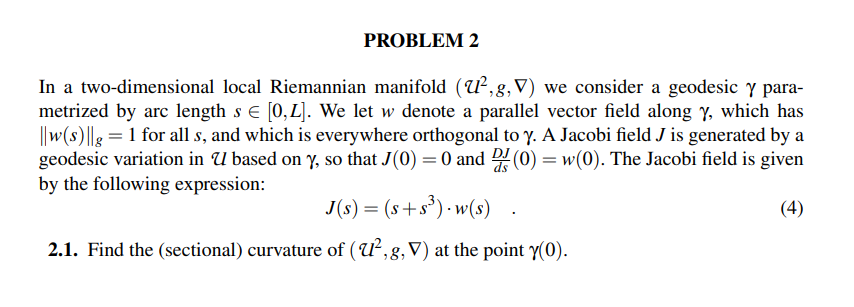

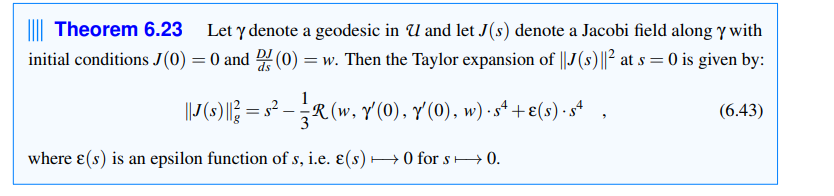
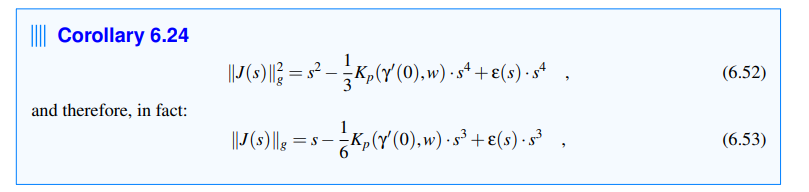

In [39]:
s, K_p, epsilon = sp.symbols('s K_p epsilon', real=True)

w = sp.Function('w')(s)

J = (s+s**3)*w

display(J)

eq = sp.Eq(s**2 -sp.Rational(1,3)*K_p*s**4 + epsilon*s**4, J**2)
display(eq)

display(eq.subs(epsilon, 0).subs(w,1))
K = sp.solve(eq.subs(epsilon, 0).subs(w,1), K_p)[0]
display(sp.simplify(K))

display(sp.simplify(K.subs(s, 0)))

(s**3 + s)*w(s)

Eq(-K_p*s**4/3 + epsilon*s**4 + s**2, (s**3 + s)**2*w(s)**2)

Eq(-K_p*s**4/3 + s**2, (s**3 + s)**2)

-3*s**2 - 6

-6

Sectional curvature at zero is -6

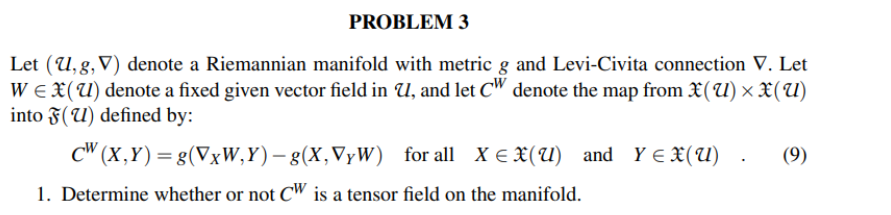

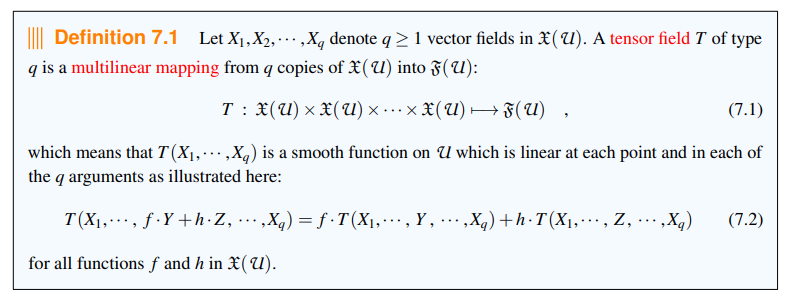

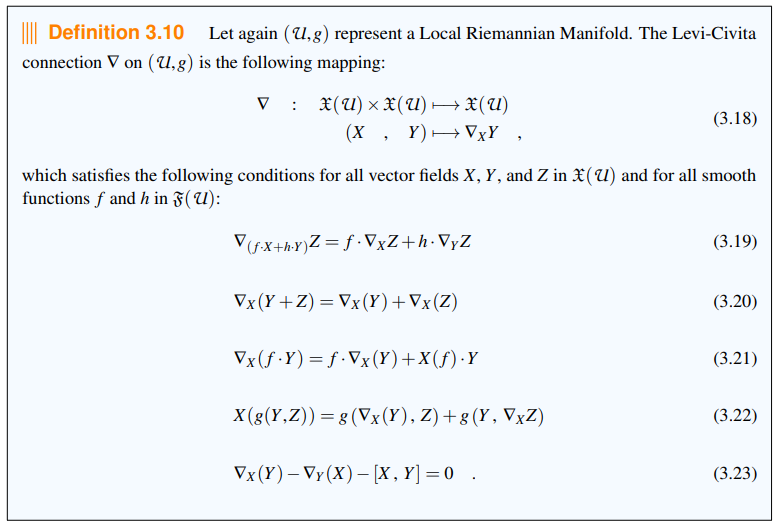

It's a tensor field if it lives up to Def 7.1. 
$$C^W(fX, Y) = g(\nabla_{fX}W, Y) - g(fX, \nabla_Y W)$$Using the property $\nabla_{fX} = f\nabla_X$ and the linearity of the metric $g$:$$C^W(fX, Y) = f g(\nabla_X W, Y) - f g(X, \nabla_Y W) = f C^W(X, Y)$$
And the same is true if we used $f Y$

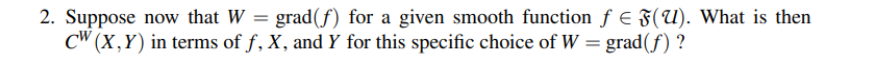
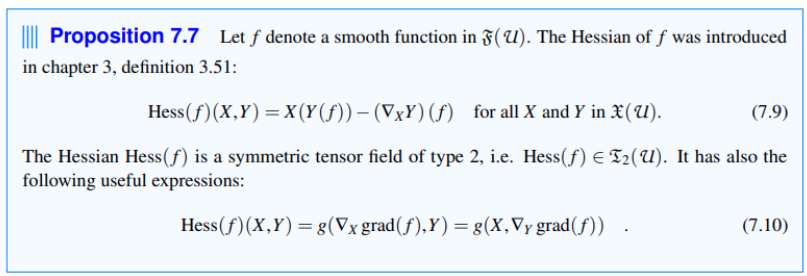

$C^W$ for $W = \text{grad}(f)$Given $W = \text{grad}(f)$, substitute this into the definition of $C^W$ : $$C^W(X, Y) = g(\nabla_X \text{grad}(f), Y) - g(X, \nabla_Y \text{grad}(f))$$ By Proposition 7.7 (7.10), we identify the terms as the Hessian of $f$: $$g(\nabla_X \text{grad}(f), Y) = \text{Hess}(f)(X, Y)$$ $$g(X, \nabla_Y \text{grad}(f)) = \text{Hess}(f)(Y, X)$$ Substituting these: $$C^W(X, Y) = \text{Hess}(f)(X, Y) - \text{Hess}(f)(Y, X)$$ Since the Hessian is symmetric ($\text{Hess}(f)(X, Y) = \text{Hess}(f)(Y, X)$):$$C^W(X, Y) = 0$$